In [1041]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
import collections
import itertools
import statsmodels

rng = np.random.default_rng()

# Block 3

## 1. Prac 6

#### 1. Низкий уровень холестерина липопротеидов высокой плотности (ХЛПВП) — фактор риска ишемической болезни сердца. Некоторые исследования свидетельствуют, что физическая нагрузка может повысить уровень ХЛПВП.
Дж. Хартунг и соавт. исследовали уровень ХЛПВП у бегунов-марафонцев, бегунов трусцой и лиц, не занимающихся спортом.
Средний уровень ХЛПВП у лиц, не занимающихся спортом, составил 43,3 мг% (стандартное отклонение 14,2 мг%), у бегунов трусцой — 58,0 мг% (стандартное отклонение 17,7 мг%) и у марафонцев — 64,8 мг% (стандартное отклонение 14,3 мг%).
Будем считать, что в каждой группе было по 70 человек.
Оцените статистическую значимость различий между группами. Найдите отличающиеся группы.

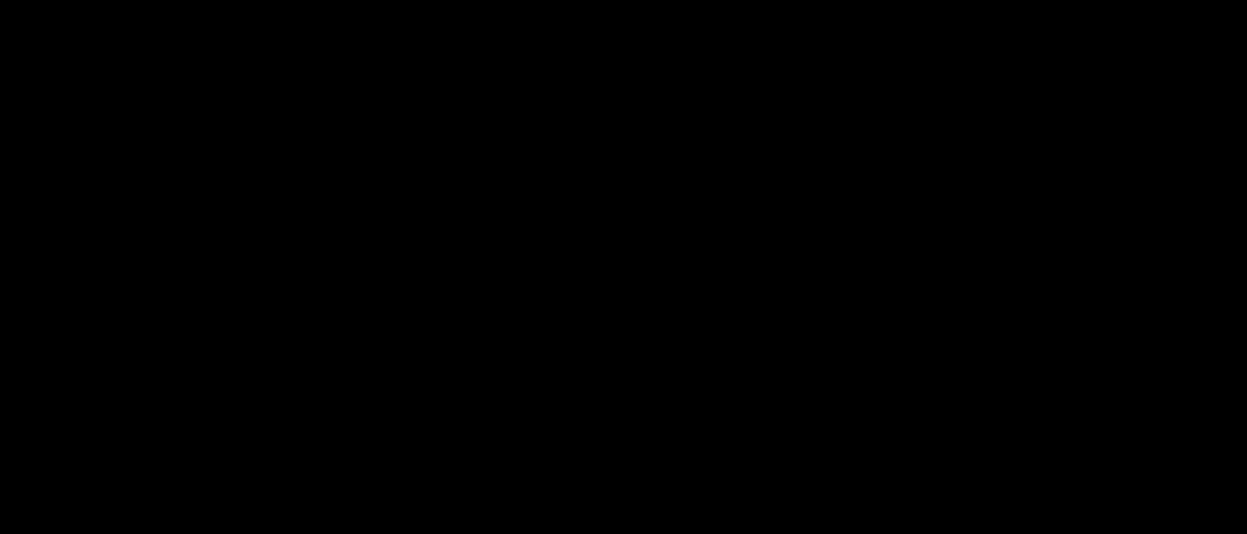

Проводим однофакторный дисперсионный анализ (ANOVA)
* $H_0: \mu_1 = \mu_2 = \mu_3$

In [1042]:
means = np.array([43.3, 58., 64.8])
stds = np.array([14.2, 17.7, 14.3])
N = 70
k = 3

# means = np.array([11.5 ,10.1, 9.1])
# stds = np.array([1.3, 2.1, 2.4])
# N = 26
# k = 3

In [1043]:
mean = means.sum() / k
mean

np.float64(55.36666666666667)

In [1044]:
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw

np.float64(239.80666666666667)

In [1045]:
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb

np.float64(8453.433333333332)

In [1046]:
F = msb / msw
F

np.float64(35.25103555642045)

In [1047]:
dfb = k - 1
dfw = k * N - k
dfb, dfw, (F_crit := stats.f.ppf(1 - 0.05, dfb, dfw))

(2, 207, np.float64(3.039508254152564))

In [1048]:
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

'35.25103555642045 > 3.039508254152564 => True - отвергаем H_0'

Есть различия в $\mu$

Применим метод Холма

In [1049]:
SE = np.sqrt(msw / N)
SE

np.float64(1.8508942497640226)

In [1050]:
combs = list(itertools.combinations(enumerate(zip(means, stds)), 2))
combs

[((0, (np.float64(43.3), np.float64(14.2))),
  (1, (np.float64(58.0), np.float64(17.7)))),
 ((0, (np.float64(43.3), np.float64(14.2))),
  (2, (np.float64(64.8), np.float64(14.3)))),
 ((1, (np.float64(58.0), np.float64(17.7))),
  (2, (np.float64(64.8), np.float64(14.3))))]

In [1051]:
p_values = []
for (i, (mean_a, std_a)), (j, (mean_b, std_b)) in combs:
    sx = np.sqrt(((N - 1) * std_a ** 2 + (N - 1) * std_b ** 2) / (2 * N - 2))
    t = np.abs(mean_a - mean_b) / (sx * np.sqrt(2 / N))

    # t = np.abs(mean_a - mean_b) / np.sqrt(msw * 2 / N)
    print(i, j, stats.t.sf(t, 2 * N - 2))
    # print(mean_a, mean_b, sx)
    p_values.append(stats.t.sf(t, 2 * N - 2))

0 1 1.292509572402871e-07
0 2 1.220075514537288e-15
1 2 0.006790456265801702


In [1052]:
# alpha = 0.05
[(i + 1) * x for i, x in enumerate(sorted(p_values))]

[np.float64(1.220075514537288e-15),
 np.float64(2.585019144805742e-07),
 np.float64(0.020371368797405108)]

Отклоняем все попарные нулевые гипотезы.
Все группы отличаются

#### 2. Работа медицинской сестры сопряжена с постоянным напряжением и тяжелыми переживаниями. Груз ответственности, не уравновешенной правом принимать решения, рождает чувство усталости, раздражения и безысходности, интересная некогда работа становится ненавистным бременем. Этот синдром не совсем точно называют опустошенностью. Считается, что его развитию особенно подвержены медицинские сестры, которые работают с наиболее тяжелыми больными.
Чтобы проверить это предположение, Э. Кин и соавт. провели опрос медицинских сестер с помощью специально разработанного опросника, позволяющего оценить опустошенность в баллах.
Медицинских сестер разделили на три группы в зависимости от тяжести состояния больных, с которыми они работали (1-я группа — наиболее тяжелые больные, 3-я — самые легкие).
Далее каждую группу разделили на две — медицинские сестры хирургических и терапевтических отделений, таким образом, получилось 6 групп по 16 медицинских сестер в каждой.
Являются ли различия между 6 группами статистически значимыми? Найдите все отличающиеся группы.


| Группа                 | 1  |  | 2    |      | 3  | |
|------------------------|---|--|------|------|--|--|
|                        | Хир. | Тер. | Хир. | Тер. | Хир. | Тер. |
| Среднее                | 49.9 | 51.2 | 57.3 | 46.4 | 43.9 | 65.2  |
| Стандартное отклонение | 14.3 | 13.4 | 14.9 | 14.7 | 16.5 | 20.5  |
| Объем выборки          | 16   | 16   | 16   | 16   | 16   | 16     |


In [1053]:
means = np.array([49.9, 51.2, 57.3, 46.4, 43.9, 65.2])
stds = np.array([14.3, 13.4, 14.9, 14.7, 16.5, 20.5])

groups = np.array([
    [1, 1, 2, 2, 3, 3],
    [1, 2, 1, 2, 1, 2],
])

N = 16
k = 6

Однофакторный анализ ANOVA

In [1054]:
mean = means.sum() / k
mean

np.float64(52.31666666666666)

In [1055]:
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw

np.float64(252.44166666666666)

In [1056]:
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb

np.float64(971.994666666667)

In [1057]:
F = msb / msw
F

np.float64(3.850373353580036)

In [1058]:
dfb = k - 1
dfw = k * N - k
F_crit = stats.f.ppf(1 - 0.05, dfb, dfw)
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

'3.850373353580036 > 2.315689237836107 => True - отвергаем H_0'

In [1059]:
stats.f.sf(F, dfb, dfw)

np.float64(0.0033039994293879433)

Критерий Тьюки

In [1060]:
Q_crit = stats.studentized_range.ppf(1 - 0.05, k, dfw)

In [1061]:
combs = list(itertools.combinations(enumerate(zip(means, stds)), 2))
se = np.sqrt(msw / N)

In [1062]:
for (i, (mean_a, std_a)), (j, (mean_b, std_b)) in combs:
    q = np.abs(mean_b - mean_a) / se
    print(i, j, q, q > Q_crit)

0 1 0.32728253037078187 False
0 2 1.862992865187521 False
0 3 0.881145274075179 False
0 4 1.5105347555574498 False
0 5 3.851863626671498 False
1 2 1.5357103348167391 False
1 3 1.2084278044459609 False
1 4 1.8378172859282316 False
1 5 3.524581096300716 False
2 3 2.7441381392627 False
2 4 3.3735276207449707 False
2 5 1.988870761483977 False
3 4 0.6293894814822707 False
3 5 4.733008900746677 True
4 5 5.362398382228948 True


Значимое различие между группами (4, 6) и (5, 6)

In [1063]:
mean = means.sum() / 3
mean
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb
F = msb / msw
F
dfb = k - 1
dfw = k * N - k
dfb, dfw, (F_crit := stats.f.ppf(1 - 0.05, dfb, dfw))
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

'212.02141748918888 > 2.315689237836107 => True - отвергаем H_0'

In [1064]:
stats.f.sf(F, dfb, dfw)

np.float64(3.387074750095336e-48)

3. Используя данные из встроенной таблицы airquality, ответьте на вопрос:
    1. в какие месяцы средняя температура воздуха в Нью-Йорке отличалась от той, что была в сентябре? Уровень значимости: 0.01.

In [1107]:
airquality = pd.read_csv("../data/airquality.csv")
airquality = airquality.drop(columns="Unnamed: 0")
airquality.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [1108]:
airquality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


In [1109]:
airquality["Month"].unique()

array([5, 6, 7, 8, 9])

In [1110]:
month = airquality.groupby("Month")
means_temp = month.mean()["Temp"]
stds_temp = month.std()["Temp"]
counts_temp = month.count()["Temp"]
means_temp, stds_temp, counts_temp

(Month
 5    65.548387
 6    79.100000
 7    83.903226
 8    83.967742
 9    76.900000
 Name: Temp, dtype: float64,
 Month
 5    6.854870
 6    6.598589
 7    4.315513
 8    6.585256
 9    8.355671
 Name: Temp, dtype: float64,
 Month
 5    31
 6    30
 7    31
 8    31
 9    30
 Name: Temp, dtype: int64)

In [1111]:
def anova(_means: np.ndarray, _stds: np.ndarray, _counts: np.ndarray, alpha=0.05):
    k = _counts.size
    N_total = _counts.sum()

    mean = (_means * _counts / N_total).sum()

    # внутри
    msw_ = (_stds ** 2 * (_counts - 1)) / (N_total - k)
    msw = msw_.sum()

    # меж
    msb_ = (_means - mean) ** 2 * _counts / (k - 1)
    msb = msb_.sum()

    F = msb / msw

    dfb = k - 1
    dfw = N_total - k
    F_crit = stats.f.ppf(1 - alpha, dfb, dfw)
    print(f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0")
    print(stats.f.sf(F, dfb, dfw))

In [1112]:
anova(means_temp, stds_temp, counts_temp, alpha=0.01)

39.846192888611974 > 3.4485079745388756 => True - отвергаем H_0
1.2765648883088407e-22


Критерий Тьюки

In [1115]:
def tukey(_means: np.ndarray, _stds: np.ndarray, _counts: np.ndarray, alpha=0.05, only_this=None):
    k = _counts.shape[0]
    N_total = _counts.sum()
    dfw = N_total - k
    Q_crit = stats.studentized_range.ppf(1 - alpha, k, dfw)
    print(f"{Q_crit = }")

    msw_ = (_stds ** 2 * (_counts - 1)) / (N_total - k)
    msw = msw_.sum()

    combs = list(itertools.combinations(enumerate(zip(_means, _stds, _counts)), 2))
    for (i, (mean_a, std_a, counts_a)), (j, (mean_b, std_b, counts_b)) in combs:
        if only_this is None or only_this in (i, j):
            se = np.sqrt(msw / 2 * (1 / counts_a + 1 / counts_b))
            q = np.abs(mean_b - mean_a) / se
            print(i, j, q, q > Q_crit)

In [1116]:
tukey(means_temp, stds_temp, counts_temp, alpha=0.01, only_this=4)

Q_crit = np.float64(4.688233883834977)
0 4 9.417497478449423 True
1 4 1.8103797916698383 False
2 4 5.8099991547921785 True
3 4 5.863522868793026 True


## 2. Prac 7

In [1073]:
def bonferony(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    N = sum(len(v) for v in type_vals.values())
    k = len(type_vals)

    alpha_bonf = alpha / k
    print(k, alpha_bonf)

    combs = list(itertools.combinations(type_vals.items(), 2))

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        std_a = type1.std()
        std_b = type2.std()

        counts_a = type1.count()
        counts_b = type2.count()

        sx = np.sqrt(((counts_a - 1) * std_a ** 2 + (counts_b - 1) * std_b ** 2) / (counts_a + counts_b - 2))
        t = np.abs(mean_a - mean_b) / (sx * np.sqrt(1 / counts_a + 1 / counts_b))

        p = stats.t.sf(t, counts_a + counts_b - 2)

        print(s1, s2, p, p > alpha_bonf)

In [1074]:
def holm(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    N = sum(len(v) for v in type_vals.values())
    k = len(type_vals)

    combs = list(itertools.combinations(type_vals.items(), 2))
    p_values = []

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        std_a = type1.std()
        std_b = type2.std()

        counts_a = type1.count()
        counts_b = type2.count()

        sx = np.sqrt(((counts_a - 1) * std_a ** 2 + (counts_b - 1) * std_b ** 2) / (counts_a + counts_b - 2))
        t = np.abs(mean_a - mean_b) / (sx * np.sqrt(1 / counts_a + 1 / counts_b))

        p = stats.t.sf(t, counts_a + counts_b - 2)

        p_values.append((p, s1, s2))

    sort = sorted(p_values, key=lambda _x: _x[0])
    m = len(sort)

    for i, x in enumerate(sort):
        p = x[0]
        print(x[1], x[2], p, (m - i), p >= alpha / (m - i))

In [1075]:
def tukey_pd(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    N = sum(len(v) for v in type_vals.values())
    k = len(type_vals)

    dfw = N - k
    Q_crit = stats.studentized_range.ppf(1 - alpha, k, dfw)
    print(f"{Q_crit = }")

    combs = list(itertools.combinations(type_vals.items(), 2))

    msw = (sprays_std ** 2 * (sprays_counts - 1) / (N - k)).sum()

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        counts_a = type1.count()
        counts_b = type2.count()

        se = np.sqrt(msw / 2 * (1 / counts_a + 1 / counts_b))
        q = np.abs(mean_a - mean_b) / se
        print(s1, s2, q, q > Q_crit)

1. Используя данные по эффективности диет, ответьте на вопрос
    1. есть ли отличия по эффекту снижения веса у разных диет?
    2. если есть, то какие из них отличаются?

In [1076]:
PRE = "pre.weight"
POST = "weight6weeks"

diets = pd.read_csv("../data/diets.csv")
diets.head()

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
0,25,NaN,41,171,60,2,60.0
1,26,NaN,32,174,103,2,103.0
2,1,0.0,22,159,58,1,54.2
3,2,0.0,46,192,60,1,54.0
4,3,0.0,55,170,64,1,63.3


In [1077]:
diff_weight = pd.DataFrame(diets[PRE] - diets[POST])
diet_diff = diets.join(diff_weight.rename(columns={0: "Diff"})).loc[:, ["Diff", "Diet"]]
diet_diff

,Diff,Diet
0,0.0,2
1,0.0,2
2,3.8,1
3,6.0,1
4,0.7,1
...,...,...
73,2.8,3
74,4.1,3
75,5.3,3
76,9.2,3


In [1078]:
diet_types = diet_diff.groupby("Diet")
diet_types = {k: diet_diff.loc[v, "Diff"] for k, v in diet_types.groups.items()}
diet_types

{1: 2     3.8
 3     6.0
 4     0.7
 5     2.9
 6     2.8
 7     2.0
 8     2.0
 9     8.5
 10    1.9
 11    3.1
 12    1.5
 13    3.0
 14    3.6
 15    0.9
 45   -0.6
 46    1.1
 47    4.5
 48    4.1
 49    9.0
 50    2.4
 51    3.9
 52    3.5
 53    5.1
 54    3.5
 Name: Diff, dtype: float64,
 2: 0     0.0
 1     0.0
 16   -2.1
 17    2.0
 18    1.7
 19    4.3
 20    7.0
 21    0.6
 22    2.7
 23    3.6
 24    3.0
 25    2.0
 26    4.2
 27    4.7
 28    3.3
 29   -0.5
 55    4.2
 56    2.4
 57    5.8
 58    3.5
 59    5.3
 60    1.7
 61    5.4
 62    6.1
 63    7.9
 64   -1.4
 65    4.3
 Name: Diff, dtype: float64,
 3: 30    7.0
 31    5.6
 32    3.4
 33    6.8
 34    7.8
 35    5.4
 36    6.8
 37    7.2
 38    7.0
 39    7.3
 40    0.9
 41    7.6
 42    4.1
 43    6.3
 44    5.0
 66    2.5
 67    0.9
 68    3.5
 69    0.5
 70    2.8
 71    8.6
 72    4.5
 73    2.8
 74    4.1
 75    5.3
 76    9.2
 77    6.1
 Name: Diff, dtype: float64}

In [1079]:
{k: stats.shapiro(v) for k, v in diet_types.items()}

{1: ShapiroResult(statistic=np.float64(0.9255313246138968), pvalue=np.float64(0.07748633505906959)),
 2: ShapiroResult(statistic=np.float64(0.9855912340453256), pvalue=np.float64(0.9611748496261021)),
 3: ShapiroResult(statistic=np.float64(0.9601254566120733), pvalue=np.float64(0.3720400277004397))}

In [1080]:
bonferony(diet_types)

3 0.016666666666666666
1 2 0.3425334430702927 True
1 3 0.003322190824870596 False
2 3 0.0012799513226491982 False


In [1081]:
holm(diet_types)

2 3 0.0012799513226491982 3 False
1 3 0.003322190824870596 2 False
1 2 0.3425334430702927 1 True


In [1082]:
tukey_pd(diet_types)

Q_crit = np.float64(3.381545521998548)
1 2 0.3755323244468559 False
1 3 2.5323058094456976 False
2 3 2.9973309420594867 False


In [1083]:
tk = stats.tukey_hsd(*diet_types.values())
print(tk)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.274     0.912    -1.332     1.881
 (0 - 2)     -1.848     0.020    -3.455    -0.242
 (1 - 0)     -0.274     0.912    -1.881     1.332
 (1 - 2)     -2.122     0.005    -3.681    -0.564
 (2 - 0)      1.848     0.020     0.242     3.455
 (2 - 1)      2.122     0.005     0.564     3.681



In [1084]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tk = pairwise_tukeyhsd(endog=diet_diff["Diff"], groups=diet_diff["Diet"])
tk.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
1,2,-0.2741,0.9125,-1.8806,1.3325,False
1,3,1.8481,0.0201,0.2416,3.4547,True
2,3,2.1222,0.0048,0.5636,3.6808,True


2.	Используя данные по инсектицидным спреям (data(InsectSprays), определите, отличаются ли спреи по эффективности
    1.	Выполните Дисперсионный анализ по Краскелу-Уоллису вручную (рассчитайте значение критерия Краскала—Уоллиса по формуле);
    2.	Воспользуйтесь стандартной функцией kruskal.test() и сравните результат

In [1085]:
insect_sprays = pd.read_csv("../data/InsectSprays.csv")
insect_sprays.drop(columns="Unnamed: 0", inplace=True)
insect_sprays.head()

,count,spray
0,10,A
1,7,A
2,20,A
3,14,A
4,14,A


In [1086]:
N = len(insect_sprays)
N

72

In [1087]:
rank = pd.DataFrame(insect_sprays["count"].rank()).rename(columns={"count": "rank"})

sprays = insect_sprays.join(rank)
sprays.head()

,count,spray,rank
0,10,A,40.0
1,7,A,36.0
2,20,A,64.5
3,14,A,52.5
4,14,A,52.5


In [1088]:
len(sprays["rank"].unique())

24

In [1089]:
sprays_sum = sprays.groupby("spray").sum()
sprays_mean = sprays.groupby("spray").mean()["rank"]
sprays_std = sprays.groupby("spray").std()["count"]
sprays_counts = sprays.groupby("spray").count()["count"]

sprays_counts, sprays_mean

(spray
 A    12
 B    12
 C    12
 D    12
 E    12
 F    12
 Name: count, dtype: int64,
 spray
 A    52.166667
 B    54.833333
 C    11.458333
 D    25.583333
 E    19.333333
 F    55.625000
 Name: rank, dtype: float64)

In [1090]:
R = (N + 1) / 2
std_R = (N ** 2 - 1) / 12
R, std_R

(36.5, 431.9166666666667)

In [1091]:
D = sprays_counts * (sprays_mean - R) ** 2
D = D.sum()
H = D * 12 / (N * (N + 1))
D, H

(np.float64(23859.291666666668), np.float64(54.473268645357685))

In [1092]:
k = sprays_counts.size

k, stats.chi2.sf(H, df=k - 1)

(6, np.float64(1.675194121518081e-10))

In [1093]:
spray_types = {k: insect_sprays.loc[v]["count"] for k, v in insect_sprays.groupby("spray").groups.items()}

stats.kruskal(*spray_types.values())

KruskalResult(statistic=np.float64(54.691344622371446), pvalue=np.float64(1.510844439418511e-10))

3.	Проведите попарные сравнения и найдите спреи, которые значимо отличаются по эффективности
    3.	Используйте поправку Бонферони
    4.	Используйте поправку Холма
    5.	Сравните результаты предыдущих двух тестов с тем, что даёт критерий Тьюки


Бонферрони

In [1094]:
bonferony(spray_types)

6 0.008333333333333333
A B 0.32730654171728724 True
A C 1.2816307339658136e-08 False
A D 1.4821079009781418e-06 False
A E 7.143188918312492e-08 False
A F 0.17326618972502122 True
B C 9.479323242703386e-10 False
B D 1.3350465348847288e-07 False
B E 4.868591036699042e-09 False
B F 0.27321403894927854 True
C D 0.0027489255289808567 False
C E 0.037567032637501656 True
C F 4.9958585873777914e-08 False
D E 0.060581152103038605 True
D F 2.0398614852264425e-06 False
E F 2.148995998794177e-07 False


Холм

In [1095]:
holm(spray_types)

B C 9.479323242703386e-10 15 False
B E 4.868591036699042e-09 14 False
A C 1.2816307339658136e-08 13 False
C F 4.9958585873777914e-08 12 False
A E 7.143188918312492e-08 11 False
B D 1.3350465348847288e-07 10 False
E F 2.148995998794177e-07 9 False
A D 1.4821079009781418e-06 8 False
D F 2.0398614852264425e-06 7 False
C D 0.0027489255289808567 6 False
C E 0.037567032637501656 5 True
D E 0.060581152103038605 4 True
A F 0.17326618972502122 3 True
B F 0.27321403894927854 2 True
A B 0.32730654171728724 1 True


Тьюки

In [1096]:
tukey_pd(spray_types)

Q_crit = np.float64(4.150850725830619)
A B 0.7360590726723687 False
A C 10.967280182818286 True
A D 8.464679335732233 True
A E 9.71597975927526 True
A F 1.9137535889481583 False
B C 11.703339255490654 True
B D 9.200738408404602 True
B E 10.452038831947629 True
B F 1.1776945162757895 False
C D 2.5026008470860517 False
C E 1.2513004235430256 False
C F 12.881033771766443 True
D E 1.251300423543026 False
D F 10.378432924680391 True
E F 11.629733348223418 True


4.	При ишемической болезни сердца курение может вызвать приступ стенокардии. Это связано с тем, что никотин увеличивает потребность миокарда в кислороде, а окись углерода связывается с гемоглобином, тем самым снижая поступление кислорода. Однако не способствуют ли развитию приступов и другие компоненты табачного дыма? Чтобы выяснить это, У. Аронов определил у 12 больных ишемической болезнью сердца продолжительность физической нагрузки до развития приступа стенокардии. У каждого больного опыт проводили до и после выкуривания пяти безникотиновых сигарет, а затем до и после вдыхания эквивалентного количества окиси углерода. Были получены следующие результаты. Длительность нагрузки до развития приступа стенокардии, секунды.
Какие выводы позволяют сделать эти данные?

| Бальной | Курение безникотиновых сигарет | | Вдыхание окиси углерода | |
|---------|--------------------------------|-|-------------------------|-|
|         | До                              | После    | До    | После    |
| 1       | 289                             | 155      | 281   | 177      |
| 2       | 203                             | 117      | 186   | 125      |
| 3       | 359                             | 187      | 372   | 238      |
| 4       | 243                             | 134      | 254   | 165      |
| 5       | 232                             | 135      | 219   | 153      |
| 6       | 210                             | 119      | 225   | 148      |
| 7       | 251                             | 145      | 264   | 180      |
| 8       | 246                             | 121      | 237   | 144      |
| 9       | 224                             | 136      | 212   | 152      |
| 10      | 239                             | 124      | 250   | 147      |
| 11      | 220                             | 118      | 209   | 138      |
| 12      | 211                             | 107      | 226   | 141      |

Влияют ли сигареты так же, как и углекислый газ?

In [1097]:
data_heart = np.array([
    [289, 155, 281, 177],
    [203, 117, 186, 125],
    [359, 187, 372, 238],
    [243, 134, 254, 165],
    [232, 135, 219, 153],
    [210, 119, 225, 148],
    [251, 145, 264, 180],
    [246, 121, 237, 144],
    [224, 136, 212, 152],
    [239, 124, 250, 147],
    [220, 118, 209, 138],
    [211, 107, 226, 141]
])
data_heart

array([[289, 155, 281, 177],
       [203, 117, 186, 125],
       [359, 187, 372, 238],
       [243, 134, 254, 165],
       [232, 135, 219, 153],
       [210, 119, 225, 148],
       [251, 145, 264, 180],
       [246, 121, 237, 144],
       [224, 136, 212, 152],
       [239, 124, 250, 147],
       [220, 118, 209, 138],
       [211, 107, 226, 141]])

[Используем тест Фридмана](https://en.wikipedia.org/wiki/Friedman_test)

In [1117]:
ranks = data_heart.argsort(axis=-1)
ranks

array([[1, 3, 2, 0],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 0, 2]])

In [1118]:
Rs = ranks.sum(axis=0)
Rs

array([12, 36, 12, 12])

In [1119]:
Xi = ranks.mean(axis=-1)
Ti = ranks.mean(axis=0)
Swi = ((ranks - Xi[:, None]) ** 2).sum(axis=-1)
Xi, Ti, Swi

(array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]),
 array([1., 3., 1., 1.]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [1120]:
X = ranks.sum() / ranks.size
ST = ((ranks - X) ** 2).sum()
X, ST

(np.float64(1.5), np.float64(60.0))

In [1121]:
SWI = Swi.sum()
Sf = ranks.shape[0] * ((Ti - X) ** 2).sum()
Ser = SWI - Sf

In [1122]:
Sf2 = Sf / (ranks.shape[1] - 1)
ser2 = Ser / ((ranks.shape[0] - 1) * (ranks.shape[1] - 1))

In [1123]:
F = Sf2 / ser2
F

np.float64(16.5)

In [1127]:
q_chi2 = stats.chi2.ppf(1 - 0.05, df=ranks.shape[1] - 1)
q_chi2

np.float64(7.814727903251179)

In [1128]:
q_chi2 >= F

np.False_

In [1129]:
stats.chi2.sf(F, df=ranks.shape[1] - 1)

np.float64(0.0008953949124762853)

Значит, есть различия между значениями в таблице

Нужно сравнивать попарно для определения различий средних